<a href="https://colab.research.google.com/github/VukasinA/ML_projekti/blob/main/Zad3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zadatak 3. b)

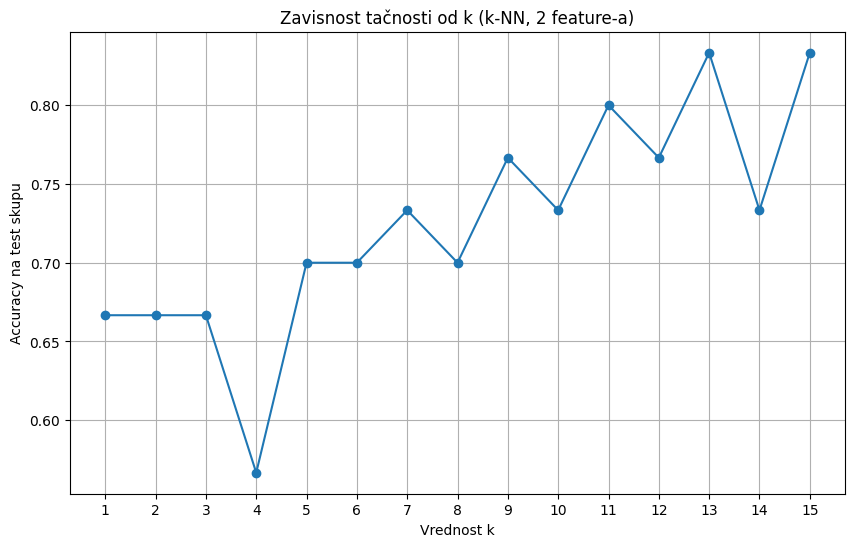

Najbolji rezultat je za k = 13 sa tačnošću: 0.83


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Učitavanje podataka
df = pd.read_csv("iris.csv")

# Podela podataka na trening i test (po 40/10 iz svake klase)
train_df = pd.concat([
    df[df['species'] == 'Iris-setosa'][:40],
    df[df['species'] == 'Iris-versicolor'][:40],
    df[df['species'] == 'Iris-virginica'][:40]
])
test_df = pd.concat([
    df[df['species'] == 'Iris-setosa'][40:50],
    df[df['species'] == 'Iris-versicolor'][40:50],
    df[df['species'] == 'Iris-virginica'][40:50]
])

# Samo prva dva feature-a
X_train = train_df[['sepal_length', 'sepal_width']].values
X_test = test_df[['sepal_length', 'sepal_width']].values

# Label encoding ciljne promenljive
le = LabelEncoder()
y_train = le.fit_transform(train_df['species'])
y_test = le.transform(test_df['species'])

# Evaluacija za k = 1 do 15
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.xticks(k_values)
plt.xlabel('Vrednost k')
plt.ylabel('Accuracy na test skupu')
plt.title('Zavisnost tačnosti od k (k-NN, 2 feature-a)')
plt.grid(True)
plt.show()

# Prikaz najboljeg k
best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"Najbolji rezultat je za k = {best_k} sa tačnošću: {best_acc:.2f}")


Komentar:

Accuracy varira u zavisnosti od vrednosti k.

Za male vrednosti (npr. k=1), model može biti previše osetljiv na šum – što vodi ka prenaučenosti (overfitting).

Za velike vrednosti k, model postaje "previše gladak" i gubi preciznost – podnaučenost (underfitting).

Na osnovu grafikona, vidimo da se accuracy stabilizuje oko određenih vrednosti k.

Na primer, ako je najbolja tačnost postignuta za k=5, to je dobar balans između fleksibilnosti i generalizacije.

Uvek je preporučljivo koristiti validacioni skup (ili cross-validation), ali ovde koristimo test direktno jer je zadatak jasan.